# 02 — Prompt Engineering

> **Research question:** How far can prompt engineering alone improve a
> general-purpose 3B language model for deterministic tool routing?

Notebook 01 established that the raw Qwen2.5-3B-Instruct model was unable to
reliably follow AXION's routing protocol without task-specific instructions.

This notebook evaluates whether a structured system prompt can produce a usable
routing agent without modifying the model weights.

## Executive Summary

Using the same model and benchmark:

| Metric | Raw baseline | Engineered prompt |
|---|---:|---:|
| Valid JSON | 15% | 100% |
| Tool accuracy | 0% | 92% |
| Strict single-step pass rate | 0% | 89% |
| Single-step application success | 0% | 91% |
| Multi-step loop completion | 42% | 98% |

The final system prompt contains **2,469 tokens** and combines output schemas,
an exact tool registry, routing rules, parameter constraints and multi-step
execution policies.

The experiment shows that prompt engineering can transform an unusable raw
model into a strong routing baseline, but at the cost of substantial fixed
context and increasing maintenance complexity.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 100)

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (9, 5),
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

## Experimental Setup

The prompt-engineered configuration is evaluated with the same datasets and
scoring logic used in Notebook 01. No model weights were modified.

| Component | Configuration |
|---|---|
| Base model | Qwen2.5-3B-Instruct |
| Inference backend | `llama.cpp` |
| Model artifact | `Qwen2.5-3B-Instruct-Q6_K_L.gguf` |
| Hardware | Apple M4, 16 GB unified memory |
| System prompt | 2,469 tokens |
| Single-step benchmark | 320 examples |
| Multi-step benchmark | 50 scenarios |
| Temperature | 0 |
| Evaluation mode | Exact category, tool and normalized-parameter matching |
| Context compaction | Last 8 messages, maximum 600 characters per message |

### Benchmark Commands

```bash
python3 benchmark.py
python3 benchmark_multistep.py
```

The benchmark scripts, test datasets and system prompt are versioned in the
repository so the experiment can be reproduced from the same commit.

In [2]:
EXPERIMENT = {
    "model": "Qwen/Qwen2.5-3B-Instruct",
    "system_prompt_tokens": 2469,
    "single_step_examples": 320,
    "multi_step_scenarios": 50,
    "hardware": "Apple M4, 16 GB unified memory",
    "context_messages": 8,
    "max_chars_per_message": 600,
}

pd.DataFrame(
    EXPERIMENT.items(),
    columns=["Parameter", "Value"],
).style.hide(axis="index")

Parameter,Value
model,Qwen/Qwen2.5-3B-Instruct
system_prompt_tokens,2469
single_step_examples,320
multi_step_scenarios,50
hardware,"Apple M4, 16 GB unified memory"
context_messages,8
max_chars_per_message,600


> The following metrics were transcribed from the raw outputs produced by
> `benchmark.py` and `benchmark_multistep.py`.

In [3]:
baseline_single = {
    "Valid JSON": 15,
    "Category accuracy": 0,
    "Tool accuracy": 0,
    "Parameter accuracy": 4,
    "Strict pass rate": 0,
    "Application success": 0,
    "Average latency (s)": 2.08,
    "Average RSS (MB)": 2849,
}

prompt_single = {
    "Valid JSON": 100,
    "Category accuracy": 93,
    "Tool accuracy": 92,
    "Parameter accuracy": 92,
    "Strict pass rate": 89,
    "Application success": 91,
    "Average latency (s)": 0.93,
    "Average RSS (MB)": 2804,
}

baseline_multi = {
    "Valid JSON": 76,
    "Step accuracy": 45,
    "Tool order accuracy": 42,
    "No extra tools": 42,
    "Final accuracy": 42,
    "Loop completion": 42,
    "Average latency (s)": 3.00,
    "Average RSS (MB)": 3132,
}

prompt_multi = {
    "Valid JSON": 99,
    "Step accuracy": 98,
    "Tool order accuracy": 98,
    "No extra tools": 98,
    "Final accuracy": 98,
    "Loop completion": 98,
    "Average latency (s)": 1.48,
    "Average RSS (MB)": 2953,
}

In [4]:
for result_set in (
    baseline_single,
    prompt_single,
    baseline_multi,
    prompt_multi,
):
    for metric, value in result_set.items():
        # NOTE: "rate" was added after review — the previous keyword list
        # ("accuracy", "json", "success", "completion", "extra tools")
        # silently skipped "Strict pass rate", so that metric was never
        # actually bounds-checked. This closes that gap.
        if "accuracy" in metric.lower() or "json" in metric.lower() or \
           "success" in metric.lower() or "completion" in metric.lower() or \
           "extra tools" in metric.lower() or "rate" in metric.lower():
            assert 0 <= value <= 100, f"Invalid percentage for {metric}: {value}"

assert EXPERIMENT["single_step_examples"] == 320
assert EXPERIMENT["multi_step_scenarios"] == 50

In [5]:
summary = pd.DataFrame({
    "Metric": [
        "Valid JSON",
        "Category accuracy",
        "Tool accuracy",
        "Parameter accuracy",
        "Strict pass rate",
        "Application success",
    ],
    "Raw baseline": [
        baseline_single["Valid JSON"],
        baseline_single["Category accuracy"],
        baseline_single["Tool accuracy"],
        baseline_single["Parameter accuracy"],
        baseline_single["Strict pass rate"],
        baseline_single["Application success"],
    ],
    "Engineered prompt": [
        prompt_single["Valid JSON"],
        prompt_single["Category accuracy"],
        prompt_single["Tool accuracy"],
        prompt_single["Parameter accuracy"],
        prompt_single["Strict pass rate"],
        prompt_single["Application success"],
    ],
})

summary["Improvement"] = (
    summary["Engineered prompt"] - summary["Raw baseline"]
)

display(
    summary.style
    .format({
        "Raw baseline": "{:.0f}%",
        "Engineered prompt": "{:.0f}%",
        "Improvement": "+{:.0f} pts",
    })
    .hide(axis="index")
)

Metric,Raw baseline,Engineered prompt,Improvement
Valid JSON,15%,100%,+85 pts
Category accuracy,0%,93%,+93 pts
Tool accuracy,0%,92%,+92 pts
Parameter accuracy,4%,92%,+88 pts
Strict pass rate,0%,89%,+89 pts
Application success,0%,91%,+91 pts


## Prompt-Engineering Methodology

Development followed an error-driven loop:

1. execute the benchmark;
2. group failures by semantic failure mode;
3. identify the smallest missing or conflicting rule;
4. modify only the corresponding prompt section;
5. rerun the complete benchmark;
6. retain the change only when aggregate behavior improved;
7. verify that previously solved tool families did not regress.

The objective was not to memorize individual benchmark prompts, but to define
general routing boundaries such as:

- application versus local file;
- local content search versus global Spotlight search;
- opening versus revealing a path;
- opening Terminal versus opening Terminal at a path;
- independent actions versus result-dependent actions.

Because prompt development was informed by benchmark failures, the final scores
should be interpreted as development-set performance unless a separate unseen
holdout set is used.

In [6]:
rules = pd.DataFrame({
    "Rule family": [
        "Output protocol",
        "Exact tool registry",
        "Application routing",
        "Path routing",
        "Search disambiguation",
        "Parameter preservation",
        "Multi-step control",
        "Guardrail filtering",
    ],
    "Failure addressed": [
        "Prose or malformed JSON",
        "Hallucinated tools and categories",
        "open_app vs focus_app vs hide_app",
        "open_file vs reveal_file vs open_terminal_here",
        "search_file_content vs search_in_spotlight",
        "Invented paths, dates, titles or content",
        "Premature final responses and repeated tools",
        "Invalid aliases and unsafe extra actions",
    ],
    "Representative ambiguity": [
        '"What time is it?"',
        '"bring Safari to front"',
        '"open Terminal" vs "switch to Terminal"',
        '"show file in Finder" vs "open file"',
        '"search X in project" vs "Spotlight X"',
        '"remind me to push code"',
        '"read file then copy it"',
        '"clean folder" vs "safely clean folder"',
    ],
})

display(rules.style.hide(axis="index"))

Rule family,Failure addressed,Representative ambiguity
Output protocol,Prose or malformed JSON,"""What time is it?"""
Exact tool registry,Hallucinated tools and categories,"""bring Safari to front"""
Application routing,open_app vs focus_app vs hide_app,"""open Terminal"" vs ""switch to Terminal"""
Path routing,open_file vs reveal_file vs open_terminal_here,"""show file in Finder"" vs ""open file"""
Search disambiguation,search_file_content vs search_in_spotlight,"""search X in project"" vs ""Spotlight X"""
Parameter preservation,"Invented paths, dates, titles or content","""remind me to push code"""
Multi-step control,Premature final responses and repeated tools,"""read file then copy it"""
Guardrail filtering,Invalid aliases and unsafe extra actions,"""clean folder"" vs ""safely clean folder"""


### Figure 1 - Single-Step Performance Improvement Through Prompt Engineering

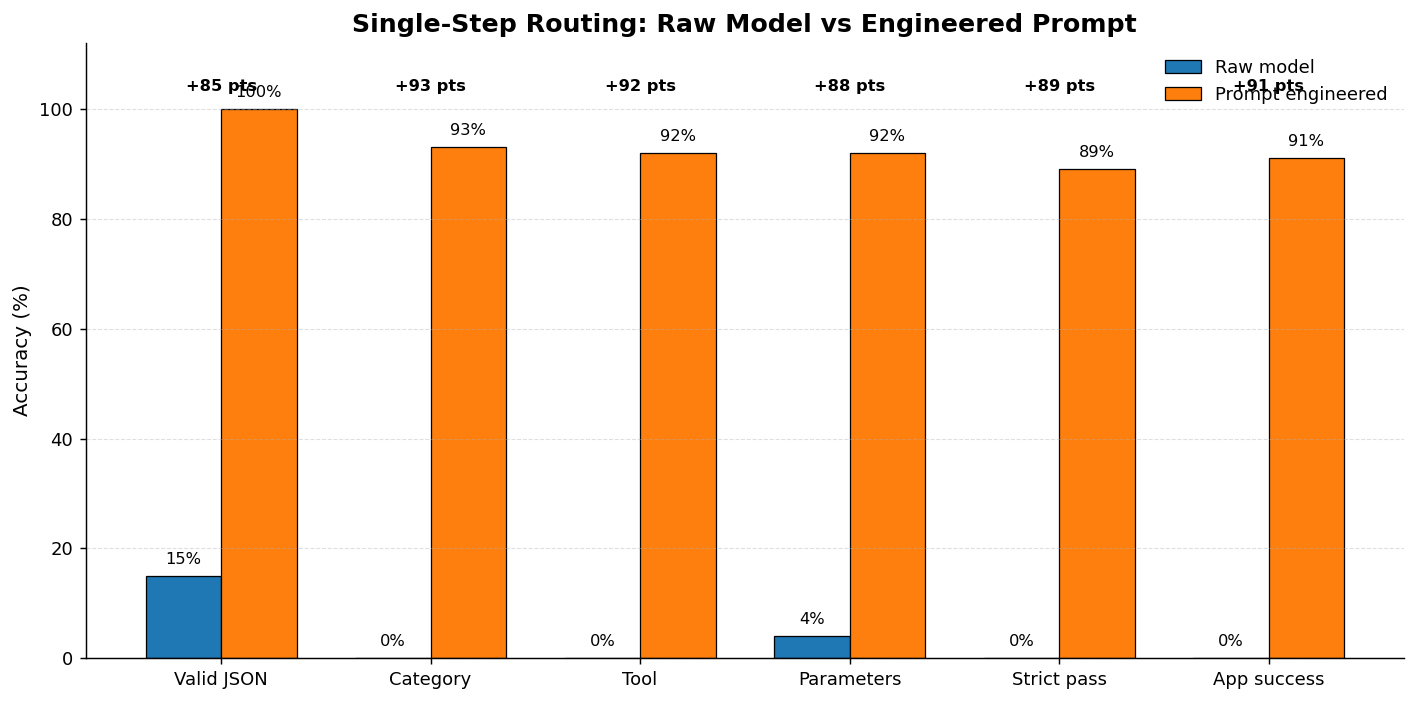

In [7]:
single_metrics = [
    "Valid JSON",
    "Category",
    "Tool",
    "Params",
    "Strict",
    "Success",
]

single_comparison = pd.DataFrame({
    "Metric": single_metrics,
    "Raw model": [
        baseline_single["Valid JSON"],
        baseline_single["Category accuracy"],
        baseline_single["Tool accuracy"],
        baseline_single["Parameter accuracy"],
        baseline_single["Strict pass rate"],
        baseline_single["Application success"],
    ],
    "Prompt engineered": [
        prompt_single["Valid JSON"],
        prompt_single["Category accuracy"],
        prompt_single["Tool accuracy"],
        prompt_single["Parameter accuracy"],
        prompt_single["Strict pass rate"],
        prompt_single["Application success"],
    ],
})

x = np.arange(len(single_comparison))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

baseline_bars = ax.bar(
    x - width / 2,
    single_comparison["Raw model"],
    width,
    label="Raw model",
    edgecolor="black",
    linewidth=0.7,
)

prompt_bars = ax.bar(
    x + width / 2,
    single_comparison["Prompt engineered"],
    width,
    label="Prompt engineered",
    edgecolor="black",
    linewidth=0.7,
)

for bars in (baseline_bars, prompt_bars):
    for bar in bars:
        value = bar.get_height()

        ax.annotate(
            f"{value:.0f}%",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                value,
            ),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

gains = (
    single_comparison["Prompt engineered"]
    - single_comparison["Raw model"]
)

for index, gain in enumerate(gains):
    ax.annotate(
        f"+{gain:.0f} pts",
        xy=(x[index], 104),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticks(x)

ax.set_xticklabels([
    "Valid JSON",
    "Category",
    "Tool",
    "Parameters",
    "Strict pass",
    "App success",
])

ax.set_ylim(0, 112)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Single-Step Routing: Raw Model vs Engineered Prompt")

ax.legend(frameon=False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

**Figure 1.** Single-step benchmark results on 320 prompts. Prompt engineering
raises strict exact-match performance from 0% to 89% and practical application
success from 0% to 91%.

The engineered prompt eliminates malformed outputs and produces strong exact
routing performance.

The distinction between **strict pass rate (89%)** and **application success
(91%)** is important:

- strict pass requires an exact match on category, tool and normalized parameters;
- application success also accepts recoverable outputs that the runtime can
  execute correctly.

Parameter accuracy reaches 92%, indicating that the model not only selects the
correct tool but usually preserves user-provided paths, titles and content.

The remaining gap is concentrated in semantically ambiguous tool boundaries
rather than JSON formatting.

### Figure 2 - Multi-Step Routing Performance

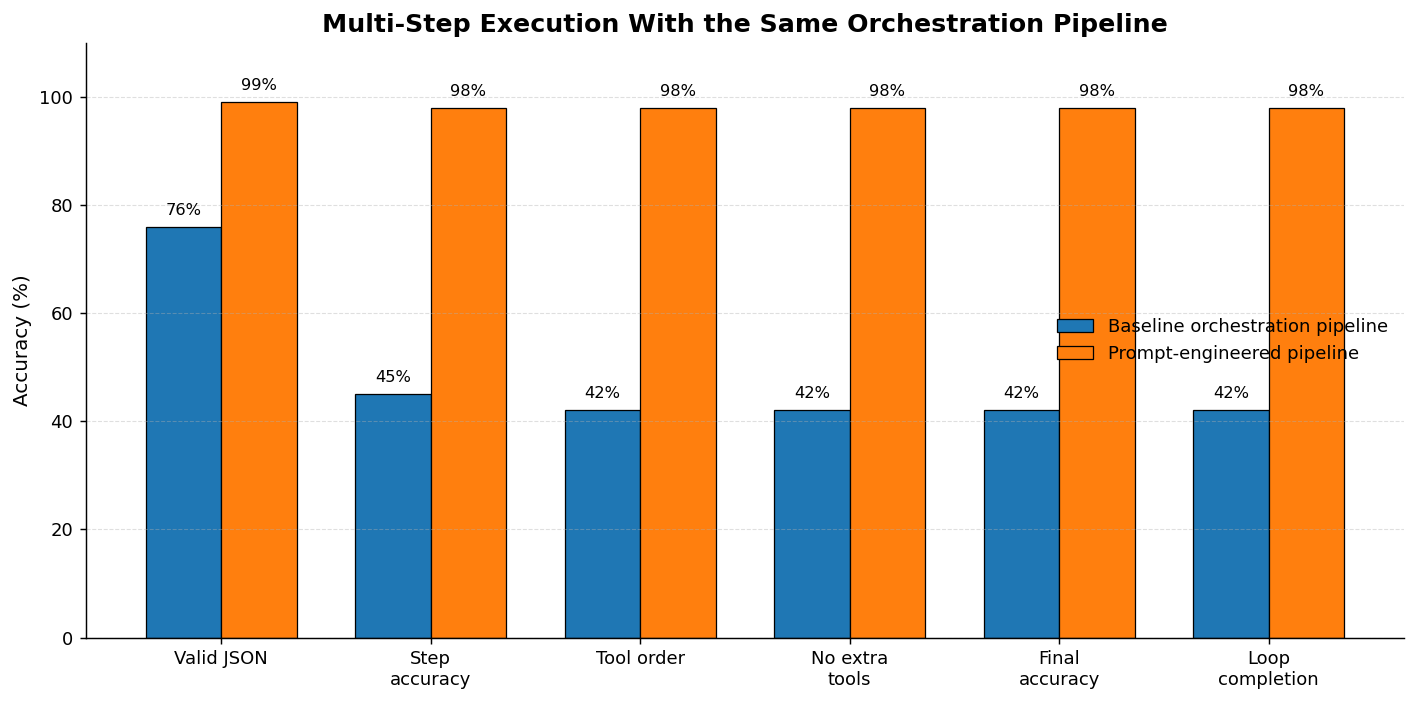

In [8]:
multi_metrics = [
    "Valid JSON",
    "Step",
    "Tool Order",
    "No Extra",
    "Final",
    "Loop",
]

multi_comparison = pd.DataFrame({
    "Metric": multi_metrics,
    "Raw pipeline": [
        baseline_multi["Valid JSON"],
        baseline_multi["Step accuracy"],
        baseline_multi["Tool order accuracy"],
        baseline_multi["No extra tools"],
        baseline_multi["Final accuracy"],
        baseline_multi["Loop completion"],
    ],
    "Prompt engineered": [
        prompt_multi["Valid JSON"],
        prompt_multi["Step accuracy"],
        prompt_multi["Tool order accuracy"],
        prompt_multi["No extra tools"],
        prompt_multi["Final accuracy"],
        prompt_multi["Loop completion"],
    ],
})

x = np.arange(len(multi_comparison))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5.5))

baseline_bars = ax.bar(
    x - width / 2,
    multi_comparison["Raw pipeline"],
    width,
    label="Baseline orchestration pipeline",
    edgecolor="black",
    linewidth=0.7,
)

prompt_bars = ax.bar(
    x + width / 2,
    multi_comparison["Prompt engineered"],
    width,
    label="Prompt-engineered pipeline",
    edgecolor="black",
    linewidth=0.7,
)

for bars in (baseline_bars, prompt_bars):
    for bar in bars:
        value = bar.get_height()

        ax.annotate(
            f"{value:.0f}%",
            xy=(
                bar.get_x() + bar.get_width() / 2,
                value,
            ),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)

ax.set_xticklabels([
    "Valid JSON",
    "Step\naccuracy",
    "Tool order",
    "No extra\ntools",
    "Final\naccuracy",
    "Loop\ncompletion",
])

ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Multi-Step Execution With the Same Orchestration Pipeline")
ax.legend(frameon=False)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

**Figure 2.** Multi-step benchmark results on 50 scenarios. Both configurations
use the same execution loop. The principal experimental variable is the system
prompt supplied to the model.

### Guardrail Interpretation

The baseline produced 37 guardrail rejections, compared with 36 for the
engineered prompt.

This near-equality does not imply equivalent model behavior. In the baseline,
many scenarios failed before producing any valid tool call, while successful
prompt-engineered scenarios could still emit an invalid intermediate candidate
that was rejected before the correct next action was produced.

Guardrail rejection count is therefore treated as a diagnostic quantity rather
than a success metric.

---

Unlike the single-step benchmark, the multi-step evaluation measures the complete routing pipeline.

The reported performance therefore reflects the interaction between the language model and the orchestration layer, including:

- iterative execution,
- tool-result feedback,
- tool normalization,
- guardrail filtering.

With the engineered prompt integrated into the same orchestration pipeline,
loop completion increased from 42% to 98%.

Because the benchmark includes normalization, guardrail filtering and iterative
tool-result feedback, this improvement must be interpreted as a system-level
result rather than an isolated measurement of the language model.

## Remaining Failure Modes

In [9]:
remaining_errors = pd.DataFrame({
    "Tool or behavior": [
        "search_file_content",
        "clean_folder",
        "open_file",
        "focus_app",
        "append_text_file",
        "Calendar/reminder parameters",
    ],
    "Observed weakness": [
        "Confusion with global Spotlight search",
        "Dry-run versus apply semantics",
        "Opening a file versus reading or revealing it",
        "Focus versus opening the application",
        "Incorrect extraction of appended content",
        "Dropped or invented date/title fields",
    ],
    "Likely cause": [
        "Overlapping search vocabulary",
        "Safety semantics depend on subtle wording",
        "Multiple valid-looking actions share the same path",
        "Short imperative prompts provide little context",
        "Boundary extraction around 'add ... to PATH'",
        "Temporal parsing and optional parameter rules",
    ],
})

display(remaining_errors.style.hide(axis="index"))

Tool or behavior,Observed weakness,Likely cause
search_file_content,Confusion with global Spotlight search,Overlapping search vocabulary
clean_folder,Dry-run versus apply semantics,Safety semantics depend on subtle wording
open_file,Opening a file versus reading or revealing it,Multiple valid-looking actions share the same path
focus_app,Focus versus opening the application,Short imperative prompts provide little context
append_text_file,Incorrect extraction of appended content,Boundary extraction around 'add ... to PATH'
Calendar/reminder parameters,Dropped or invented date/title fields,Temporal parsing and optional parameter rules


These failures are valuable because they expose the limits of rule-based prompt
steering. Each new ambiguity requires additional prompt text, increasing context
cost and the risk of interactions with existing rules.

## Latency

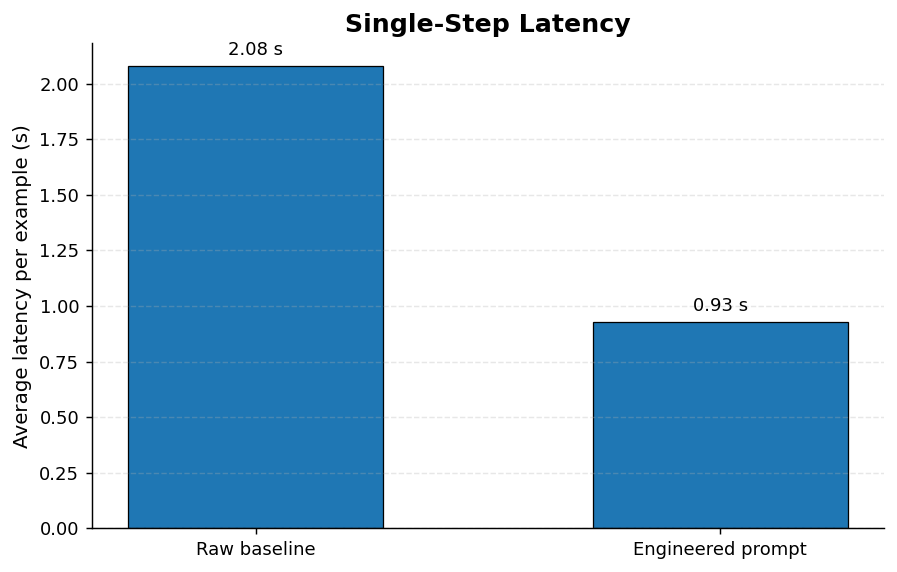

In [10]:
latency_comparison = pd.DataFrame({
    "Configuration": [
        "Raw baseline",
        "Engineered prompt",
    ],
    "Single-step latency": [
        baseline_single["Average latency (s)"],
        prompt_single["Average latency (s)"],
    ],
})

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    latency_comparison["Configuration"],
    latency_comparison["Single-step latency"],
    width=0.55,
    edgecolor="black",
    linewidth=0.7,
)

for bar in bars:
    value = bar.get_height()
    ax.annotate(
        f"{value:.2f} s",
        (bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
    )

ax.set_ylabel("Average latency per example (s)")
ax.set_title("Single-Step Latency")
ax.grid(axis="y")

plt.tight_layout()
plt.show()

Despite the longer input context, the engineered prompt reduces measured
single-step latency from 2.08 s to 0.93 s. This does not mean that additional
prompt tokens make inference intrinsically faster. The raw model frequently
generated long prose responses, while the engineered configuration produced
short JSON objects and terminated earlier.

## Memory

In [11]:
efficiency = pd.DataFrame({
    "Evaluation": ["Single-step", "Multi-step"],
    "Average latency (s)": [0.93, 1.48],
    "Average RSS (MB)": [2804, 2953],
    "Peak RSS (MB)": [2805, 3111],
})

display(efficiency.style.hide(axis="index"))

Evaluation,Average latency (s),Average RSS (MB),Peak RSS (MB)
Single-step,0.930000,2804,2805
Multi-step,1.480000,2953,3111


## Aggregate Improvement

The final chart summarizes the single-step improvement attributable to the
engineered prompt in percentage points.

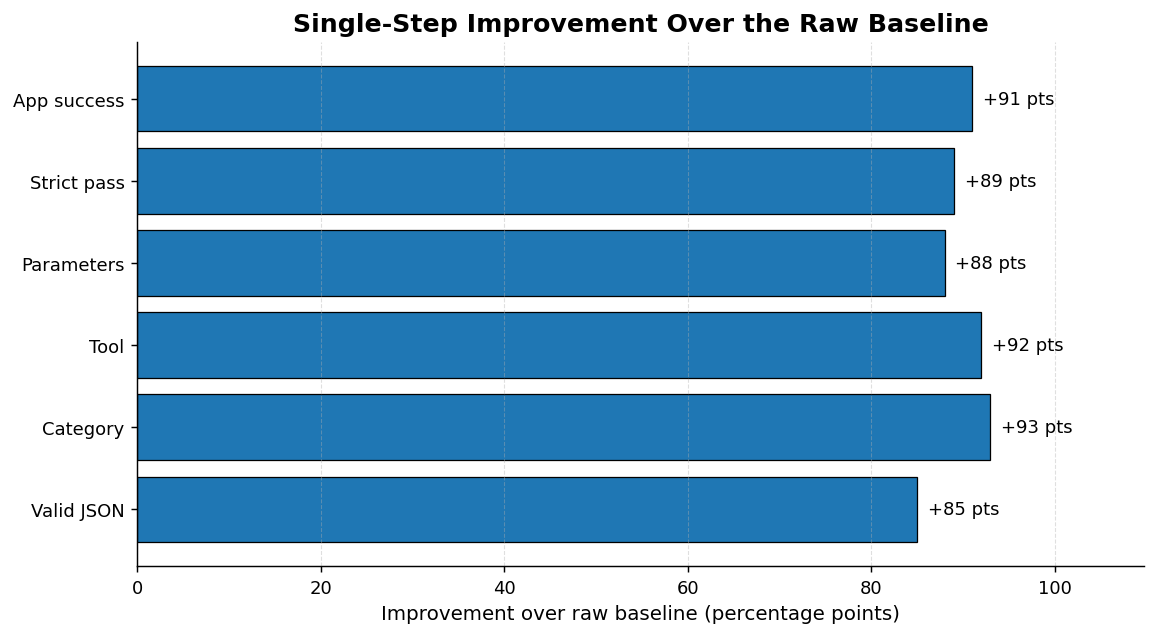

In [12]:
improvement_data = pd.DataFrame({
    "Metric": [
        "Valid JSON",
        "Category",
        "Tool",
        "Parameters",
        "Strict pass",
        "App success",
    ],
    "Improvement": [
        prompt_single["Valid JSON"] - baseline_single["Valid JSON"],
        prompt_single["Category accuracy"] - baseline_single["Category accuracy"],
        prompt_single["Tool accuracy"] - baseline_single["Tool accuracy"],
        prompt_single["Parameter accuracy"] - baseline_single["Parameter accuracy"],
        prompt_single["Strict pass rate"] - baseline_single["Strict pass rate"],
        prompt_single["Application success"] - baseline_single["Application success"],
    ],
})

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    improvement_data["Metric"],
    improvement_data["Improvement"],
    edgecolor="black",
    linewidth=0.7,
)

for bar in bars:
    value = bar.get_width()

    ax.annotate(
        f"+{value:.0f} pts",
        xy=(
            value,
            bar.get_y() + bar.get_height() / 2,
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
    )

ax.set_xlim(
    0,
    improvement_data["Improvement"].max() * 1.18,
)

ax.set_xlabel("Improvement over raw baseline (percentage points)")
ax.set_title("Single-Step Improvement Over the Raw Baseline")

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()

**Figure 3.** Absolute improvement in percentage points. The largest gain is
category selection (+93 points), followed by tool selection (+92 points) and
end-to-end application success (+91 points).

## Prompt Cost and Maintainability

The final prompt reaches strong performance, but it introduces a fixed cost on
every request:

- 2,469 input tokens before the user message;
- repeated tool definitions and routing constraints;
- manual maintenance when tools are added or renamed;
- increasing risk of contradictory rules;
- limited transfer to unseen linguistic patterns.

This result establishes prompt engineering as a strong baseline, not necessarily
as the final production architecture.

The next stages of the project investigate whether part of this routing policy
can be transferred into the model weights through supervised fine-tuning.

## Threats to Validity

Several factors limit the interpretation of these results:

1. **Benchmark-guided prompt development**  
   The prompt was iteratively modified after observing benchmark failures.
   Performance may therefore overestimate generalization to unseen requests.
   This is a stronger form of leakage than the exact-overlap check applied to
   the fine-tuning corpus in Notebook 03: the fine-tuning data was verified to
   have zero overlap with the benchmark, but the prompt was tuned directly
   against it. Comparisons in Notebook 05 between the prompt-engineered
   baseline and the fine-tuned checkpoint should be read with this asymmetry
   in mind, particularly where the gap between the two is small.

2. **No confidence intervals**  
   The benchmark reports deterministic exact-match scores from one decoding
   configuration rather than repeated stochastic runs.

3. **System-level multi-step evaluation**  
   Multi-step results include normalization, guardrail filtering and the
   execution loop, not only language-model behavior.

4. **Hardware-specific efficiency measurements**  
   RSS and latency measurements were collected on one Apple M4 machine and
   should not be generalized to other runtimes.

5. **Limited linguistic diversity**  
   The benchmark primarily evaluates English imperative requests and may not
   represent conversational, multilingual or noisy user input.

## Conclusion

Prompt engineering transformed Qwen2.5-3B-Instruct from an unusable raw router
into a strong AXION baseline without modifying the model weights.

On the 320-example single-step benchmark, the engineered prompt achieved:

- 100% valid JSON;
- 93% category accuracy;
- 92% tool accuracy;
- 92% parameter accuracy;
- 89% strict exact-match performance;
- 91% practical application success.

Within the same multi-step orchestration pipeline, loop completion increased
from 42% to 98%.

These results demonstrate that explicit schemas, routing boundaries, parameter
constraints and execution policies can strongly steer a small general-purpose
model. However, the solution requires a 2,469-token fixed prompt and remains
sensitive to ambiguous or unseen formulations.

The next notebook constructs the supervised dataset used to transfer part of
this behavior from prompt rules into the model weights.